>Note:
In this file, we want to do an experiment by splitting the most important feature (Smoker)  
and adding a Polynomial feature to clarify the Non-Linear pattern, then comparing it with the previous model.

## Import Library

In [1]:
import pandas as pd
import numpy as np
import shap
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

## Load Dataset

In [2]:
train_data = pd.read_pickle('../data/preprocess/train_data.pkl')
test_data = pd.read_pickle('../data/preprocess/test_data.pkl')

In [3]:
train_data.head(2)

,age,gender,bmi,bloodpressure,diabetic,children,smoker,claim,age_group,bmi_category,bp_status,reg_northwest,reg_southeast,reg_southwest
1148,32.0,1,26.7,115,1,1,1,26109.33,2,2,0,1,0,0
807,51.0,0,25.7,83,1,0,0,11454.02,3,2,0,1,0,0


## Feature Engginering

In [4]:
# Creates an interaction feature between smoking status and other risk factors.
def create_interaction(df):
    df['smoker_bmi'] = df['smoker'] * df['bmi']
    df['smoker_age'] = df['smoker'] * df['age']
    df['smoker_bmi_age'] = df['smoker'] * df['bmi'] * df['age']
    df['smoker_diabetic'] = df['smoker'] * df['diabetic']
    df['smoker_age_group'] = df['smoker'] * df['age_group']
    return df

In [5]:
# Capturing non-linear relationships: insurance costs typically rise more extreme
# good for Linear model
def create_polynomials(df):
    df['bmi_squared'] = df['bmi'] ** 2
    df['age_squared'] = df['age'] ** 2
    return df

In [6]:
# Measures the proportion of body weight to blood pressure.
# Add +1 to avoid division by zero.
def bmi_bp_ratio(df):
    df['bmi_bp_ratio'] = df['bmi'] / (df['bloodpressure'] + 1)
    return df

In [7]:
def health_risk_score(df):
    # Give penalty points for each bad condition
    score = 0
    score += (df['smoker'] == 1).astype(int) * 3          
    score += (df['bmi'] > 30).astype(int) * 2             
    score += (df['bloodpressure'] >= 140).astype(int) * 1
    
    # normalize to 0/1 scale
    df['health_risk_score'] = score / 6
    return df

In [8]:
# Create special interaction features for non-smoker groups.
def get_non_smoker(df):
    df['nonsmoker'] = 1 - df['smoker']
    df['nonsmoker_bmi'] = df['nonsmoker'] * df['bmi']
    df['nonsmoker_age'] = df['nonsmoker'] * df['age']
    df['nonsmoker_diabetic_bmi'] = df['nonsmoker'] * df['diabetic'] * df['bmi']
    df['nonsmoker_bp_age'] = df['nonsmoker'] * df['bloodpressure'] * df['age']
    return df

In [9]:
# Create interaction features to capture risk complications of diabetes sufferers.
def more_daibetic(df):
    df['diabetic_bmi'] = df['diabetic'] * df['bmi']
    df['daibetic_age'] = df['diabetic'] * df['age']
    return df

In [10]:
def pipeline_feat_engg(df):
    df = create_interaction(df)
    df = bmi_bp_ratio(df)
    df = create_polynomials(df)
    df = health_risk_score(df)
    df = get_non_smoker(df)
    df = more_daibetic(df)
    return df

In [11]:
# call func
train_data = pipeline_feat_engg(train_data)
test_data = pipeline_feat_engg(test_data)

In [12]:
train_data.head()

,age,gender,bmi,bloodpressure,diabetic,children,smoker,claim,age_group,bmi_category,...,bmi_squared,age_squared,health_risk_score,nonsmoker,nonsmoker_bmi,nonsmoker_age,nonsmoker_diabetic_bmi,nonsmoker_bp_age,diabetic_bmi,daibetic_age
1148,32.0,1,26.7,115,1,1,1,26109.33,2,2,...,712.89,1024.0,0.500000,0,0.0,0.0,0.0,0.0,26.7,32.0
807,51.0,0,25.7,83,1,0,0,11454.02,3,2,...,660.49,2601.0,0.000000,1,25.7,51.0,25.7,4233.0,25.7,51.0
1287,32.0,0,39.0,96,1,0,1,42983.46,2,3,...,1521.00,1024.0,0.833333,0,0.0,0.0,0.0,0.0,39.0,32.0
590,38.0,0,23.4,96,1,3,0,8252.28,3,1,...,547.56,1444.0,0.000000,1,23.4,38.0,23.4,3648.0,23.4,38.0
1188,37.0,1,28.3,88,0,3,1,32787.46,3,2,...,800.89,1369.0,0.500000,0,0.0,0.0,0.0,0.0,0.0,0.0


## Simple EDA for check the correlation each feat

In [13]:
# Check Linear Cor

def check_corr(df):
    pearson_corr = df.corr(method='pearson')['claim']
    spearman_corr = df.corr(method='spearman')['claim']
    comparison = pd.DataFrame({'Pearson (Linear)': pearson_corr, 'Spearman (Non-Linear)': spearman_corr})
    
    # sort by the largest absolute value, 
    # but why Spearman? because we want to know about the features that have an overall influence
    comparison['abs_spearman'] = comparison['Spearman (Non-Linear)'].abs()
    # sort by abs_spearman column then delete that column so it doesn't get in the way
    comparison = comparison.sort_values(by='abs_spearman', ascending=False).drop(columns=['abs_spearman'])
    return comparison.style.background_gradient(cmap='coolwarm', axis=0)

check_corr(train_data)

,Pearson (Linear),Spearman (Non-Linear)
claim,1.000000,1.000000
smoker_bmi,0.836468,0.665175
smoker_bmi_age,0.792075,0.658023
nonsmoker,-0.777491,-0.656681
smoker,0.777491,0.656681
smoker_age_group,0.750439,0.651866
smoker_age,0.731557,0.650287
health_risk_score,0.722491,0.535126
nonsmoker_age,-0.652451,-0.447311
nonsmoker_bmi,-0.699828,-0.416212


## Prepare Data

In [14]:
X_train = train_data.drop('claim', axis=1)
y_train = train_data['claim']

X_test = test_data.drop('claim', axis=1)
y_test = test_data['claim']

## Test new feat with model

In [15]:
models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42)
} 

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        'Scenario': 'full feature',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })

df_results = pd.DataFrame(results).sort_values(by='MAE').reset_index(drop=True)
df_results = df_results.style.format({col: '{:,.2f}' for col in ['MAE', 'RMSE', 'R2']})
display(df_results) 

,Scenario,Model,MAE,RMSE,R2
0,full feature,XGBoost,"3,885.74","5,391.57",0.82
1,full feature,RandomForest,"3,972.12","5,334.12",0.83


### Cross-Validation for check predict model

In [16]:
results_cv = []

for name, model in models.items():
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')
    mae_mean = -cv_scores.mean()
    mae_std = cv_scores.std()
    
    results_cv.append({
        'Scenario': 'Cross_validation',
        'Model': name,
        'MAE_mean': mae_mean,
        'MAE_std': mae_std 
    })

df_results_cv = pd.DataFrame(results_cv).sort_values(by='MAE_mean').reset_index(drop=True)
df_results_cv = df_results_cv.style.format({col: '{:,.2f}' for col in ['MAE_mean', 'MAE_std']})
display(df_results_cv) 

,Scenario,Model,MAE_mean,MAE_std
0,Cross_validation,RandomForest,"4,185.89",169.42
1,Cross_validation,XGBoost,"4,423.85",252.59


## Cek Importance Feature

In [17]:
importance_feature = []

for name, model in models.items():
    importance = model.feature_importances_
    
    feature_df = pd.DataFrame({
        'Feature': X_train.columns,
        'Importance': importance,
        'Model': name
    }) 
    importance_feature.append(feature_df)
all_importance_feat = pd.concat(importance_feature)

df_importance_pivot = all_importance_feat.pivot(index='Feature', columns='Model', values='Importance')
df_importance_pivot['Average'] = df_importance_pivot.mean(axis=1)
df_top_feat = df_importance_pivot.sort_values(by='Average', ascending=False).head(10)
df_top_feat = df_top_feat.style.format('{:.2f}')
display(df_top_feat)

Model,RandomForest,XGBoost,Average
Feature,,,
smoker_bmi,0.66,0.72,0.69
health_risk_score,0.08,0.23,0.16
bloodpressure,0.06,0.01,0.04
bmi_bp_ratio,0.03,0.00,0.02
nonsmoker_bp_age,0.03,0.00,0.02
children,0.02,0.00,0.01
bmi_squared,0.02,0.00,0.01
bmi,0.01,0.00,0.01
daibetic_age,0.01,0.00,0.01


### With Shap

#### RandomForest

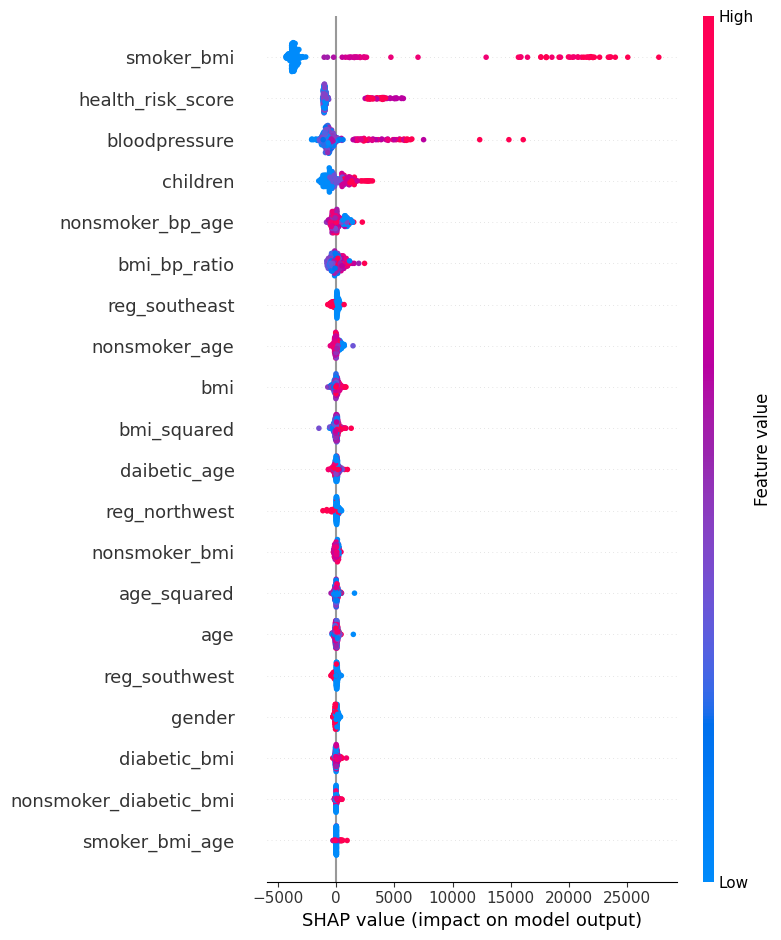

In [18]:
explaner_rf = shap.TreeExplainer(models['RandomForest'])
shap_value_rf = explaner_rf.shap_values(X_test)
shap.summary_plot(shap_value_rf, X_test)

#### XGBoost

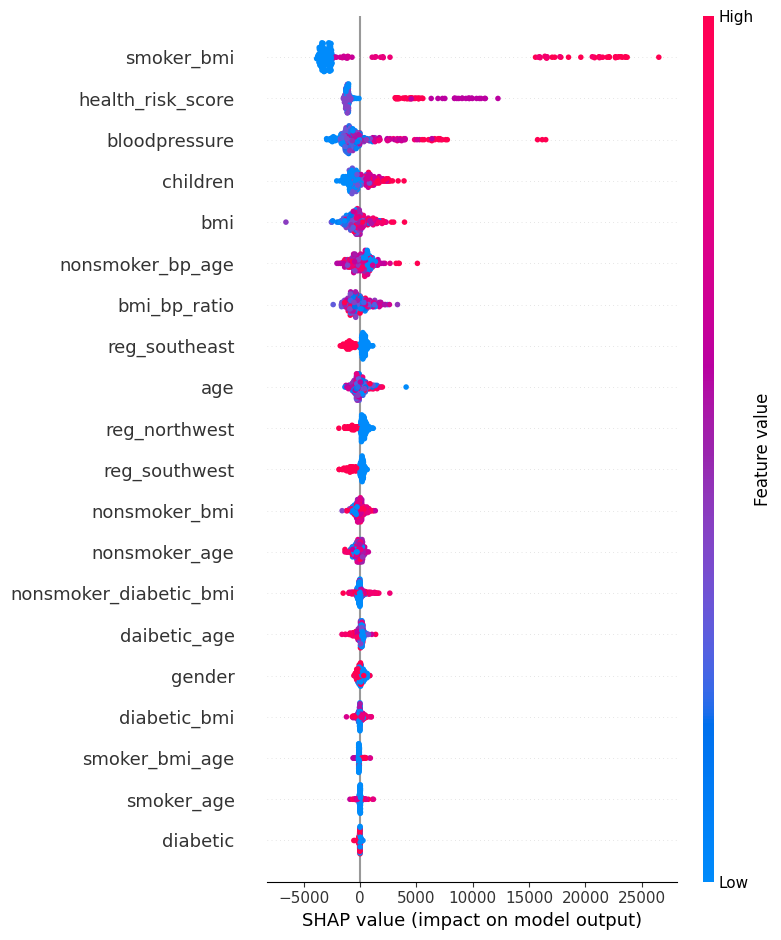

In [19]:
explaner_rf = shap.TreeExplainer(models['XGBoost'])
shap_value_rf = explaner_rf.shap_values(X_test)
shap.summary_plot(shap_value_rf, X_test)

## Feature Selection

we try to git model with top feat to see the result

In [20]:
X_train.columns

Index(['age', 'gender', 'bmi', 'bloodpressure', 'diabetic', 'children',
       'smoker', 'age_group', 'bmi_category', 'bp_status', 'reg_northwest',
       'reg_southeast', 'reg_southwest', 'smoker_bmi', 'smoker_age',
       'smoker_bmi_age', 'smoker_diabetic', 'smoker_age_group', 'bmi_bp_ratio',
       'bmi_squared', 'age_squared', 'health_risk_score', 'nonsmoker',
       'nonsmoker_bmi', 'nonsmoker_age', 'nonsmoker_diabetic_bmi',
       'nonsmoker_bp_age', 'diabetic_bmi', 'daibetic_age'],
      dtype='str')

In [21]:
selected_feature = [
    'smoker_bmi',
    'smoker_bmi_age',
    'smoker_age',
    'smoker_diabetic',
    'nonsmoker_age',
    'nonsmoker_bmi',
    'nonsmoker_bp_age',
    'bloodpressure',
    'health_risk_score',
    'children'
]

for name, model in models.items():
    model.fit(X_train[selected_feature], y_train)
    preds = model.predict(X_test[selected_feature])
    
    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)
    
    results.append({
        'Scenario': 'Top feature',
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    })
    

df_results = pd.DataFrame(results).sort_values(by='MAE').reset_index(drop=True)
df_results = df_results.style.format({col: '{:,.2f}' for col in ['MAE', 'RMSE', 'R2']})
display(df_results) 

,Scenario,Model,MAE,RMSE,R2
0,full feature,XGBoost,"3,885.74","5,391.57",0.82
1,full feature,RandomForest,"3,972.12","5,334.12",0.83
2,Top feature,RandomForest,"4,065.71","5,499.06",0.82
3,Top feature,XGBoost,"4,125.95","5,682.28",0.80


## Save the Data 

In [22]:
train_data[selected_feature].to_pickle('../data/preprocess/ready_train_data.pkl')
test_data[selected_feature].to_pickle('../data/preprocess/ready_test_data.pkl')